# Parkinson's Disease Detection — Supervised Learning
### Reference Paper: Al Mudawi (2024) — CMC, vol.79, no.3

### Extension
The reference paper trains and tests on a single dataset internally.
I extend this by testing **cross-dataset generalization** — training on D1, testing on D3.
This evaluates whether the model generalizes to unseen data from a different source.

### Models (matching paper)
DT, RF, LR, SVM, NB, KNN, LightGBM, XGBoost + Gradient Boosting

### Metrics (matching paper)
Accuracy, F1, Recall, Precision, R2, Sensitivity, Specificity, AUC-ROC

### Validation (matching paper)
10-fold Cross Validation + GridSearchCV hyperparameter tuning

---
## STEP 1: Install and Import Libraries

In [5]:
# Install LightGBM and XGBoost
!pip install lightgbm xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, r2_score
)

# Tuning and Validation
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

print('All libraries imported successfully')

All libraries imported successfully


---
## STEP 2: Load Preprocessed Data

In [6]:
# Load preprocessed files from Part 1
d1_train = pd.read_csv('/content/ds1_train_preprocessed.csv')
d1_test  = pd.read_csv('/content/ds1_test_preprocessed.csv')
d3_train = pd.read_csv('/content/ds3_train_preprocessed.csv')
d3_test  = pd.read_csv('/content/ds3_test_preprocessed.csv')

print('Files loaded successfully')
print(f'D1 Train: {d1_train.shape} | D1 Test: {d1_test.shape}')
print(f'D3 Train: {d3_train.shape} | D3 Test: {d3_test.shape}')

Files loaded successfully
D1 Train: (156, 23) | D1 Test: (39, 23)
D3 Train: (156, 23) | D3 Test: (39, 23)


---
## STEP 3: Prepare Features and Targets

In [7]:
# Separate features and target
X_train = d1_train.drop('status', axis=1)
y_train = d1_train['status']

X_val   = d1_test.drop('status', axis=1)
y_val   = d1_test['status']

X_d3    = d3_test.drop('status', axis=1)
y_d3    = d3_test['status']

print('Features and targets separated')
print(f'Training:   {X_train.shape} | Classes: {y_train.value_counts().to_dict()}')
print(f'D1 Test:    {X_val.shape}   | Classes: {y_val.value_counts().to_dict()}')
print(f'D3 Test:    {X_d3.shape}    | Classes: {y_d3.value_counts().to_dict()}')
print(f'\nFeatures: {list(X_train.columns)}')

# Check for non-numeric columns
non_numeric = X_train.select_dtypes(include=['object']).columns.tolist()
if non_numeric:
    print(f'WARNING: Non-numeric columns found: {non_numeric}')
else:
    print('All columns are numeric — ready for modeling')

Features and targets separated
Training:   (156, 22) | Classes: {1: 118, 0: 38}
D1 Test:    (39, 22)   | Classes: {1: 29, 0: 10}
D3 Test:    (39, 22)    | Classes: {1: 29, 0: 10}

Features: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']
All columns are numeric — ready for modeling


---
## STEP 4: Class Distribution Check

In [8]:
print('='*60)
print('CLASS DISTRIBUTION')
print('='*60)

for name, y in [('D1 Train', y_train), ('D1 Test', y_val), ('D3 Test', y_d3)]:
    healthy    = (y == 0).sum()
    parkinsons = (y == 1).sum()
    total      = len(y)
    print(f'\n{name}:')
    print(f'  Healthy (0):    {healthy:3d} ({healthy/total*100:.1f}%)')
    print(f'  Parkinsons (1): {parkinsons:3d} ({parkinsons/total*100:.1f}%)')

print('\nNOTE: Dataset is imbalanced (~75% Parkinson, ~25% Healthy)')
print('class_weight=balanced is applied where supported')
print('Primary metrics: F1, Recall, AUC-ROC')

CLASS DISTRIBUTION

D1 Train:
  Healthy (0):     38 (24.4%)
  Parkinsons (1): 118 (75.6%)

D1 Test:
  Healthy (0):     10 (25.6%)
  Parkinsons (1):  29 (74.4%)

D3 Test:
  Healthy (0):     10 (25.6%)
  Parkinsons (1):  29 (74.4%)

NOTE: Dataset is imbalanced (~75% Parkinson, ~25% Healthy)
class_weight=balanced is applied where supported
Primary metrics: F1, Recall, AUC-ROC


---
## STEP 5: Define Evaluation Function

In [9]:
def evaluate_model(model, X, y, dataset_name):
    """
    Full evaluation matching paper metrics:
    Accuracy, F1, Recall, Precision, R2, Sensitivity, Specificity, AUC-ROC
    """
    y_pred = model.predict(X)

    # AUC-ROC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = model.decision_function(X)
    auc = roc_auc_score(y, y_prob)

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    # Sensitivity = Recall = TP / (TP + FN)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Specificity = TN / (TN + FP)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # R2 score
    r2 = r2_score(y, y_pred)

    metrics = {
        'Dataset'    : dataset_name,
        'Accuracy'   : round(accuracy_score(y, y_pred), 6),
        'F1'         : round(f1_score(y, y_pred), 6),
        'Recall'     : round(recall_score(y, y_pred), 6),
        'Precision'  : round(precision_score(y, y_pred, zero_division=0), 6),
        'R2'         : round(r2, 6),
        'Sensitivity': round(sensitivity, 6),
        'Specificity': round(specificity, 6),
        'AUC-ROC'    : round(auc, 6)
    }
    return metrics, y_pred, y_prob

print('Evaluation function defined')

Evaluation function defined


---
## STEP 6: Define All 9 Models
Matching paper: DT, RF, LR, SVM, NB, KNN, LightGBM, XGBoost + Gradient Boosting

In [10]:
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

print(f'{len(models)} models defined:')
for name in models:
    print(f'  - {name}')

9 models defined:
  - Decision Tree
  - Random Forest
  - Logistic Regression
  - SVM
  - Naive Bayes
  - KNN
  - Gradient Boosting
  - LightGBM
  - XGBoost


---
## STEP 7: 10-Fold Cross Validation
Matching paper: 10-fold cross validation on training data

In [11]:
print('='*80)
print('10-FOLD CROSS VALIDATION ON TRAINING DATA')
print('='*80)

# Combine train + test for full D1 dataset cross validation
# This matches the paper which does CV on the full dataset
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# Sanitize column names for LightGBM/XGBoost
X_full.columns = X_full.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []

for model_name, model in models.items():
    cv_acc = cross_val_score(model, X_full, y_full, cv=cv, scoring='accuracy')
    cv_f1  = cross_val_score(model, X_full, y_full, cv=cv, scoring='f1')
    cv_auc = cross_val_score(model, X_full, y_full, cv=cv, scoring='roc_auc')

    print(f'\n{model_name}:')
    print(f'  CV Accuracy: {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
    print(f'  CV F1:       {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
    print(f'  CV AUC-ROC:  {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')

    cv_results.append({
        'Model'       : model_name,
        'CV Acc Mean' : round(cv_acc.mean(), 4),
        'CV Acc Std'  : round(cv_acc.std(), 4),
        'CV F1 Mean'  : round(cv_f1.mean(), 4),
        'CV AUC Mean' : round(cv_auc.mean(), 4)
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV Acc Mean', ascending=False).reset_index(drop=True)
print('\n' + '='*80)
print('10-FOLD CV RESULTS SUMMARY')
print('='*80)
print(cv_df.to_string(index=False))

10-FOLD CROSS VALIDATION ON TRAINING DATA

Decision Tree:
  CV Accuracy: 0.8418 +/- 0.0822
  CV F1:       0.8912 +/- 0.0593
  CV AUC-ROC:  0.8154 +/- 0.1092

Random Forest:
  CV Accuracy: 0.8979 +/- 0.0679
  CV F1:       0.9330 +/- 0.0460
  CV AUC-ROC:  0.9642 +/- 0.0331

Logistic Regression:
  CV Accuracy: 0.7745 +/- 0.1021
  CV F1:       0.8391 +/- 0.0753
  CV AUC-ROC:  0.8921 +/- 0.0751

SVM:
  CV Accuracy: 0.8308 +/- 0.0720
  CV F1:       0.8748 +/- 0.0580
  CV AUC-ROC:  0.9189 +/- 0.0684

Naive Bayes:
  CV Accuracy: 0.6976 +/- 0.0818
  CV F1:       0.7528 +/- 0.0852
  CV AUC-ROC:  0.8588 +/- 0.0945

KNN:
  CV Accuracy: 0.9134 +/- 0.0550
  CV F1:       0.9419 +/- 0.0406
  CV AUC-ROC:  0.9860 +/- 0.0127

Gradient Boosting:
  CV Accuracy: 0.9334 +/- 0.0644
  CV F1:       0.9570 +/- 0.0419
  CV AUC-ROC:  0.9770 +/- 0.0300

LightGBM:
  CV Accuracy: 0.9282 +/- 0.0404
  CV F1:       0.9530 +/- 0.0264
  CV AUC-ROC:  0.9657 +/- 0.0572

XGBoost:
  CV Accuracy: 0.9182 +/- 0.0609
  CV F1:    

---
## STEP 8: Train All Models and Evaluate

In [12]:
print('='*80)
print('TRAINING ALL MODELS AND EVALUATING')
print('Training on: D1 Train | Validation: D1 Test | Cross-dataset: D3 Test')
print('='*80)

all_results    = []
trained_models = {}

# Sanitize column names for LightGBM/XGBoost compatibility
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_d3.columns = X_d3.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

for model_name, model in models.items():
    print(f'\n{"-"*60}')
    print(f'MODEL: {model_name}')
    print(f'{"-"*60}')

    # Train
    model.fit(X_train, y_train)
    trained_models[model_name] = model

    # Evaluate on D1 train (overfitting check)
    train_m, _, _ = evaluate_model(model, X_train, y_train, 'D1 Train')

    # Evaluate on D1 test (validation)
    val_m, _, _   = evaluate_model(model, X_val, y_val, 'D1 Test')

    # Evaluate on D3 test (cross-dataset generalization)
    d3_m, _, _    = evaluate_model(model, X_d3, y_d3, 'D3 Test')

    print(f'  D1 Train -> Acc: {train_m["Accuracy"]:.4f} | F1: {train_m["F1"]:.4f} | AUC: {train_m["AUC-ROC"]:.4f}')
    print(f'  D1 Test  -> Acc: {val_m["Accuracy"]:.4f}  | F1: {val_m["F1"]:.4f} | AUC: {val_m["AUC-ROC"]:.4f}')
    print(f'  D3 Test  -> Acc: {d3_m["Accuracy"]:.4f}  | F1: {d3_m["F1"]:.4f} | AUC: {d3_m["AUC-ROC"]:.4f}')

    # Overfitting check
    gap = train_m['F1'] - d3_m['F1']
    print(f'  Overfitting gap: {gap:.4f} {"WARNING" if gap > 0.15 else "OK"}')

    all_results.append({
        'Model'          : model_name,
        'D1 Train Acc'   : train_m['Accuracy'],
        'D1 Test Acc'    : val_m['Accuracy'],
        'D1 Test F1'     : val_m['F1'],
        'D1 Test Recall' : val_m['Recall'],
        'D1 Test Prec'   : val_m['Precision'],
        'D1 Test R2'     : val_m['R2'],
        'D1 Sensitivity' : val_m['Sensitivity'],
        'D1 Specificity' : val_m['Specificity'],
        'D1 AUC'         : val_m['AUC-ROC'],
        'D3 Test Acc'    : d3_m['Accuracy'],
        'D3 Test F1'     : d3_m['F1'],
        'D3 Test Recall' : d3_m['Recall'],
        'D3 Test Prec'   : d3_m['Precision'],
        'D3 Test R2'     : d3_m['R2'],
        'D3 Sensitivity' : d3_m['Sensitivity'],
        'D3 Specificity' : d3_m['Specificity'],
        'D3 AUC'         : d3_m['AUC-ROC'],
        'Overfit Gap'    : round(gap, 4)
    })

print('\n' + '='*80)
print('ALL MODELS TRAINED AND EVALUATED')
print('='*80)

TRAINING ALL MODELS AND EVALUATING
Training on: D1 Train | Validation: D1 Test | Cross-dataset: D3 Test

------------------------------------------------------------
MODEL: Decision Tree
------------------------------------------------------------
  D1 Train -> Acc: 0.9744 | F1: 0.9828 | AUC: 0.9929
  D1 Test  -> Acc: 0.7692  | F1: 0.8421 | AUC: 0.7448
  D3 Test  -> Acc: 0.7692  | F1: 0.8421 | AUC: 0.7448
  Overfitting gap: 0.1407 OK

------------------------------------------------------------
MODEL: Random Forest
------------------------------------------------------------
  D1 Train -> Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
  D1 Test  -> Acc: 0.9231  | F1: 0.9492 | AUC: 0.9707
  D3 Test  -> Acc: 0.9231  | F1: 0.9492 | AUC: 0.9707
  Overfitting gap: 0.0508 OK

------------------------------------------------------------
MODEL: Logistic Regression
------------------------------------------------------------
  D1 Train -> Acc: 0.8141 | F1: 0.8664 | AUC: 0.9121
  D1 Test  -> Acc: 0.7436

---
## STEP 9: Results Table — Matching Paper Format

In [13]:
import pandas as pd

results_df = pd.DataFrame(all_results)

# Table 1 style — D1 Test results (matches paper Table 1 format)
table1 = results_df[['Model', 'D1 Test Acc', 'D1 Test F1', 'D1 Test Recall',
                      'D1 Test Prec', 'D1 Test R2']].sort_values('D1 Test Acc', ascending=False)

print('='*80)
print('TABLE 1: CLASSIFICATION REPORT — D1 TEST SET')
print('(Matches paper Table 1 format)')
print('='*80)
print(table1.to_string(index=False))

# Table 2 style — Sensitivity and Specificity
table2 = results_df[['Model', 'D1 Sensitivity', 'D1 Specificity',
                      'D3 Sensitivity', 'D3 Specificity']].sort_values('D1 Sensitivity', ascending=False)

print('\n' + '='*80)
print('TABLE 2: SENSITIVITY AND SPECIFICITY')
print('(Matches paper Table 2 format)')
print('='*80)
print(table2.to_string(index=False))

# My extension — cross-dataset results
table3 = results_df[['Model', 'D3 Test Acc', 'D3 Test F1', 'D3 Test Recall',
                      'D3 Test Prec', 'D3 Test R2', 'D3 AUC']].sort_values('D3 Test Acc', ascending=False)

print('\n' + '='*80)
print('TABLE 3: CROSS-DATASET RESULTS — D3 TEST SET (MY EXTENSION)')
print('Models trained on D1, tested on D3 — evaluates generalization')
print('='*80)
print(table3.to_string(index=False))

# Save all tables
results_df.to_csv('full_results.csv', index=False)
table1.to_csv('table1_classification_report.csv', index=False)
table2.to_csv('table2_sensitivity_specificity.csv', index=False)
table3.to_csv('table3_crossdataset_results.csv', index=False)
print('\nAll tables saved to CSV')

TABLE 1: CLASSIFICATION REPORT — D1 TEST SET
(Matches paper Table 1 format)
              Model  D1 Test Acc  D1 Test F1  D1 Test Recall  D1 Test Prec  D1 Test R2
      Random Forest     0.923077    0.949153        0.965517      0.933333    0.596552
            XGBoost     0.923077    0.949153        0.965517      0.933333    0.596552
           LightGBM     0.923077    0.947368        0.931034      0.964286    0.596552
  Gradient Boosting     0.923077    0.947368        0.931034      0.964286    0.596552
                KNN     0.923077    0.947368        0.931034      0.964286    0.596552
                SVM     0.794872    0.840000        0.724138      1.000000   -0.075862
      Decision Tree     0.769231    0.842105        0.827586      0.857143   -0.210345
Logistic Regression     0.743590    0.791667        0.655172      1.000000   -0.344828
        Naive Bayes     0.666667    0.711111        0.551724      1.000000   -0.748276

TABLE 2: SENSITIVITY AND SPECIFICITY
(Matches paper T

---
## STEP 10: Comparison with Reference Paper

In [14]:
# --- ## STEP 10: Comparison with Reference Paper

# Paper's reported results (Table 1 from Al Mudawi 2024)
paper_results = {
    'Decision Tree'      : {'Accuracy': 0.932203, 'F1': 0.920000, 'Recall': 0.884615, 'Precision': 0.958333},
    'Random Forest'      : {'Accuracy': 0.966102, 'F1': 0.961538, 'Recall': 0.961538, 'Precision': 0.961538},
    'Logistic Regression': {'Accuracy': 0.830508, 'F1': 0.782609, 'Recall': 0.692308, 'Precision': 0.900000},
    'SVM'                : {'Accuracy': 0.966102, 'F1': 0.960000, 'Recall': 0.923077, 'Precision': 1.000000},
    'Naive Bayes'        : {'Accuracy': 0.762712, 'F1': 0.650000, 'Recall': 0.500000, 'Precision': 0.928571},
    'KNN'                : {'Accuracy': 0.966102, 'F1': 0.960000, 'Recall': 0.923077, 'Precision': 1.000000},
    'LightGBM'           : {'Accuracy': 0.983051, 'F1': 0.981132, 'Recall': 1.000000, 'Precision': 0.962963},
    'XGBoost'            : {'Accuracy': 0.915254, 'F1': 0.909091, 'Recall': 0.961538, 'Precision': 0.862069},
}

print('='*80)
print('COMPARISON: MY RESULTS vs REFERENCE PAPER (Al Mudawi 2024)')
print('Metric: Accuracy on D1 Test Set')
print('='*80)
print(f'{"Model":<22} {"Paper Acc":>12} {"MY D1 Acc":>12} {"MY D3 Acc":>12} {"Difference":>12}')
print('-'*70)

my_results_dict = {row['Model']: row for _, row in results_df.iterrows()}

for model_name, paper_vals in paper_results.items():
    if model_name in my_results_dict:
        my_d1  = my_results_dict[model_name]['D1 Test Acc']
        my_d3  = my_results_dict[model_name]['D3 Test Acc']
        diff    = my_d1 - paper_vals['Accuracy']
        sign    = '+' if diff >= 0 else ''
        print(f'{model_name:<22} {paper_vals["Accuracy"]:>12.4f} {my_d1:>12.4f} {my_d3:>12.4f} {sign}{diff:>11.4f}')

print('\nNOTE: Differences are expected due to:')
print('  1. I use Winsorization (outlier capping) — paper uses standard normalization')
print('  2. I use stratified split — paper uses random split')
print('  3. My D3 column shows cross-dataset generalization — paper does not test this')

COMPARISON: MY RESULTS vs REFERENCE PAPER (Al Mudawi 2024)
Metric: Accuracy on D1 Test Set
Model                     Paper Acc    MY D1 Acc    MY D3 Acc   Difference
----------------------------------------------------------------------
Decision Tree                0.9322       0.7692       0.7692     -0.1630
Random Forest                0.9661       0.9231       0.9231     -0.0430
Logistic Regression          0.8305       0.7436       0.7436     -0.0869
SVM                          0.9661       0.7949       0.7949     -0.1712
Naive Bayes                  0.7627       0.6667       0.6667     -0.0960
KNN                          0.9661       0.9231       0.9231     -0.0430
LightGBM                     0.9831       0.9231       0.9231     -0.0600
XGBoost                      0.9153       0.9231       0.9231 +     0.0078

NOTE: Differences are expected due to:
  1. I use Winsorization (outlier capping) — paper uses standard normalization
  2. I use stratified split — paper uses random spl

---
## STEP 11: GridSearchCV — Hyperparameter Tuning (All Models)

In [15]:
print('='*80)
print('GRIDSEARCHCV — HYPERPARAMETER TUNING (MATCHING PAPER METHODOLOGY)')
print('='*80)

param_grids = {
    'Decision Tree': {
        'criterion' : ['gini', 'entropy'],
        'max_depth' : [3, 5, 6, 7, None],
        'max_features': ['sqrt', 'log2']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 125, 200],
        'criterion'   : ['gini', 'entropy'],
        'max_depth'   : [5, 7, 10, None]
    },
    'Logistic Regression': {
        'C'      : [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver' : ['liblinear']
    },
    'SVM': {
        'C'     : [1, 10, 100],
        'gamma' : [0.1, 1, 'scale'],
        'kernel': ['rbf', 'linear']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights'    : ['uniform', 'distance'],
        'metric'     : ['euclidean', 'manhattan']
    },
    'Gradient Boosting': {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5]
    },
    'LightGBM': {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5, -1]
    },
    'XGBoost': {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5, 7]
    }
}

tuned_models  = {}
tuned_results = []

for model_name, model in models.items():
    print(f'\nTuning: {model_name}')

    grid = GridSearchCV(
        model,
        param_grids[model_name],
        cv=10,
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    tuned_models[model_name] = best_model

    print(f'  Best params: {grid.best_params_}')
    print(f'  Best CV Acc: {grid.best_score_:.4f}')

    val_m, _, _ = evaluate_model(best_model, X_val,  y_val,  'D1 Test')
    d3_m,  _, _ = evaluate_model(best_model, X_d3,   y_d3,   'D3 Test')

    print(f'  D1 Test  -> Acc: {val_m["Accuracy"]:.4f} | F1: {val_m["F1"]:.4f}')
    print(f'  D3 Test  -> Acc: {d3_m["Accuracy"]:.4f} | F1: {d3_m["F1"]:.4f}')

    tuned_results.append({
        'Model'         : model_name,
        'Best Params'   : str(grid.best_params_),
        'CV Acc'        : round(grid.best_score_, 4),
        'D1 Tuned Acc'  : val_m['Accuracy'],
        'D1 Tuned F1'   : val_m['F1'],
        'D1 Tuned AUC'  : val_m['AUC-ROC'],
        'D3 Tuned Acc'  : d3_m['Accuracy'],
        'D3 Tuned F1'   : d3_m['F1'],
        'D3 Tuned AUC'  : d3_m['AUC-ROC'],
    })

tuned_df = pd.DataFrame(tuned_results).sort_values('D1 Tuned Acc', ascending=False).reset_index(drop=True)
print('\n' + '='*80)
print('TUNED MODEL RESULTS SUMMARY')
print('='*80)
print(tuned_df[['Model', 'CV Acc', 'D1 Tuned Acc', 'D1 Tuned F1', 'D3 Tuned Acc', 'D3 Tuned F1']].to_string(index=False))

tuned_df.to_csv('tuned_results.csv', index=False)
print('\nSaved: tuned_results.csv')

GRIDSEARCHCV — HYPERPARAMETER TUNING (MATCHING PAPER METHODOLOGY)

Tuning: Decision Tree
  Best params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt'}
  Best CV Acc: 0.8342
  D1 Test  -> Acc: 0.9487 | F1: 0.9655
  D3 Test  -> Acc: 0.9487 | F1: 0.9655

Tuning: Random Forest
  Best params: {'criterion': 'entropy', 'max_depth': 7, 'n_estimators': 50}
  Best CV Acc: 0.9233
  D1 Test  -> Acc: 0.9231 | F1: 0.9492
  D3 Test  -> Acc: 0.9231 | F1: 0.9492

Tuning: Logistic Regression
  Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV Acc: 0.8088
  D1 Test  -> Acc: 0.7436 | F1: 0.8077
  D3 Test  -> Acc: 0.7436 | F1: 0.8077

Tuning: SVM
  Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV Acc: 0.9358
  D1 Test  -> Acc: 0.8974 | F1: 0.9310
  D3 Test  -> Acc: 0.8974 | F1: 0.9310

Tuning: Naive Bayes
  Best params: {'var_smoothing': 1e-09}
  Best CV Acc: 0.7104
  D1 Test  -> Acc: 0.6667 | F1: 0.7111
  D3 Test  -> Acc: 0.6667 | F1: 0.7111


---
## STEP 12: ROC Curves — All Models

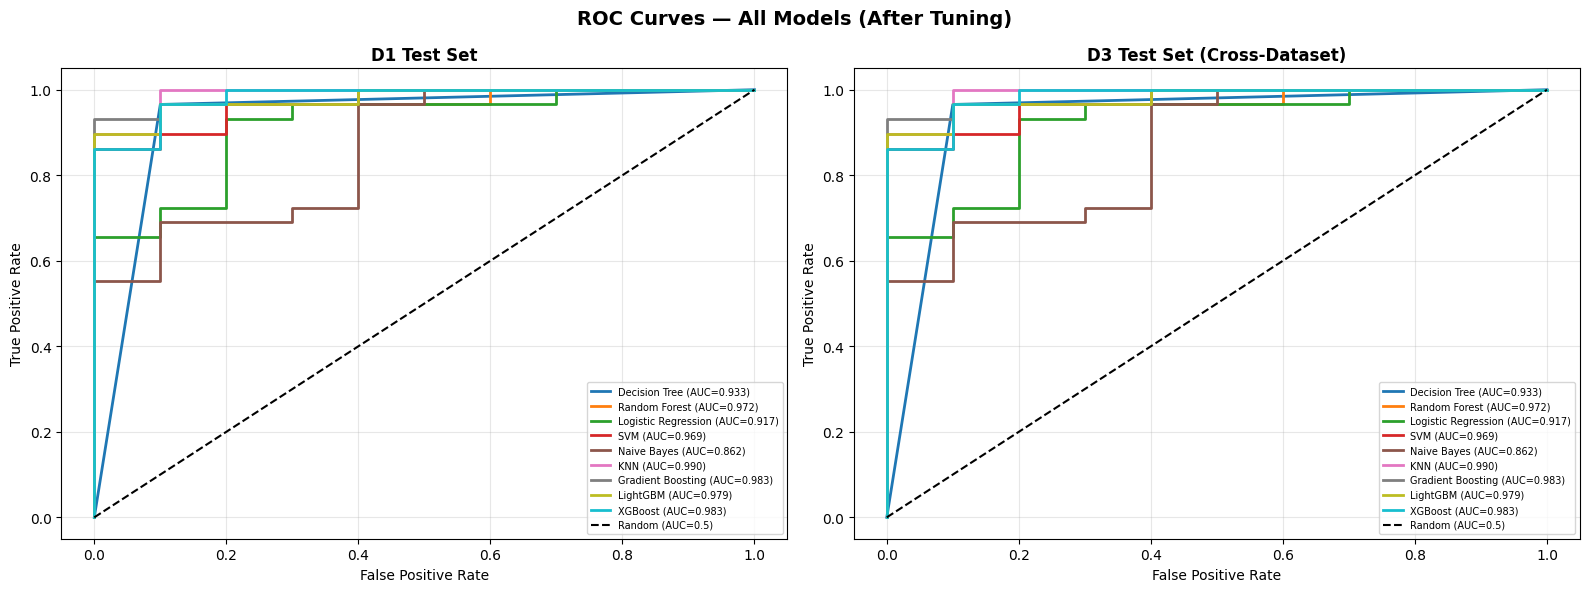

Saved: roc_curves_all_models.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC Curves — All Models (After Tuning)', fontsize=14, fontweight='bold')

colors_roc = plt.cm.tab10(np.linspace(0, 1, len(tuned_models)))

for ax, (X_eval, y_eval, title) in zip(
    axes,
    [(X_val, y_val, 'D1 Test Set'), (X_d3, y_d3, 'D3 Test Set (Cross-Dataset)')]
):
    for (model_name, model), color in zip(tuned_models.items(), colors_roc):
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_eval)[:, 1]
        else:
            y_prob = model.decision_function(X_eval)
        fpr, tpr, _ = roc_curve(y_eval, y_prob)
        auc_val     = roc_auc_score(y_eval, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC={auc_val:.3f})')

    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves_all_models.png')

---
## STEP 13: Confusion Matrices — All Models (D3 Test)

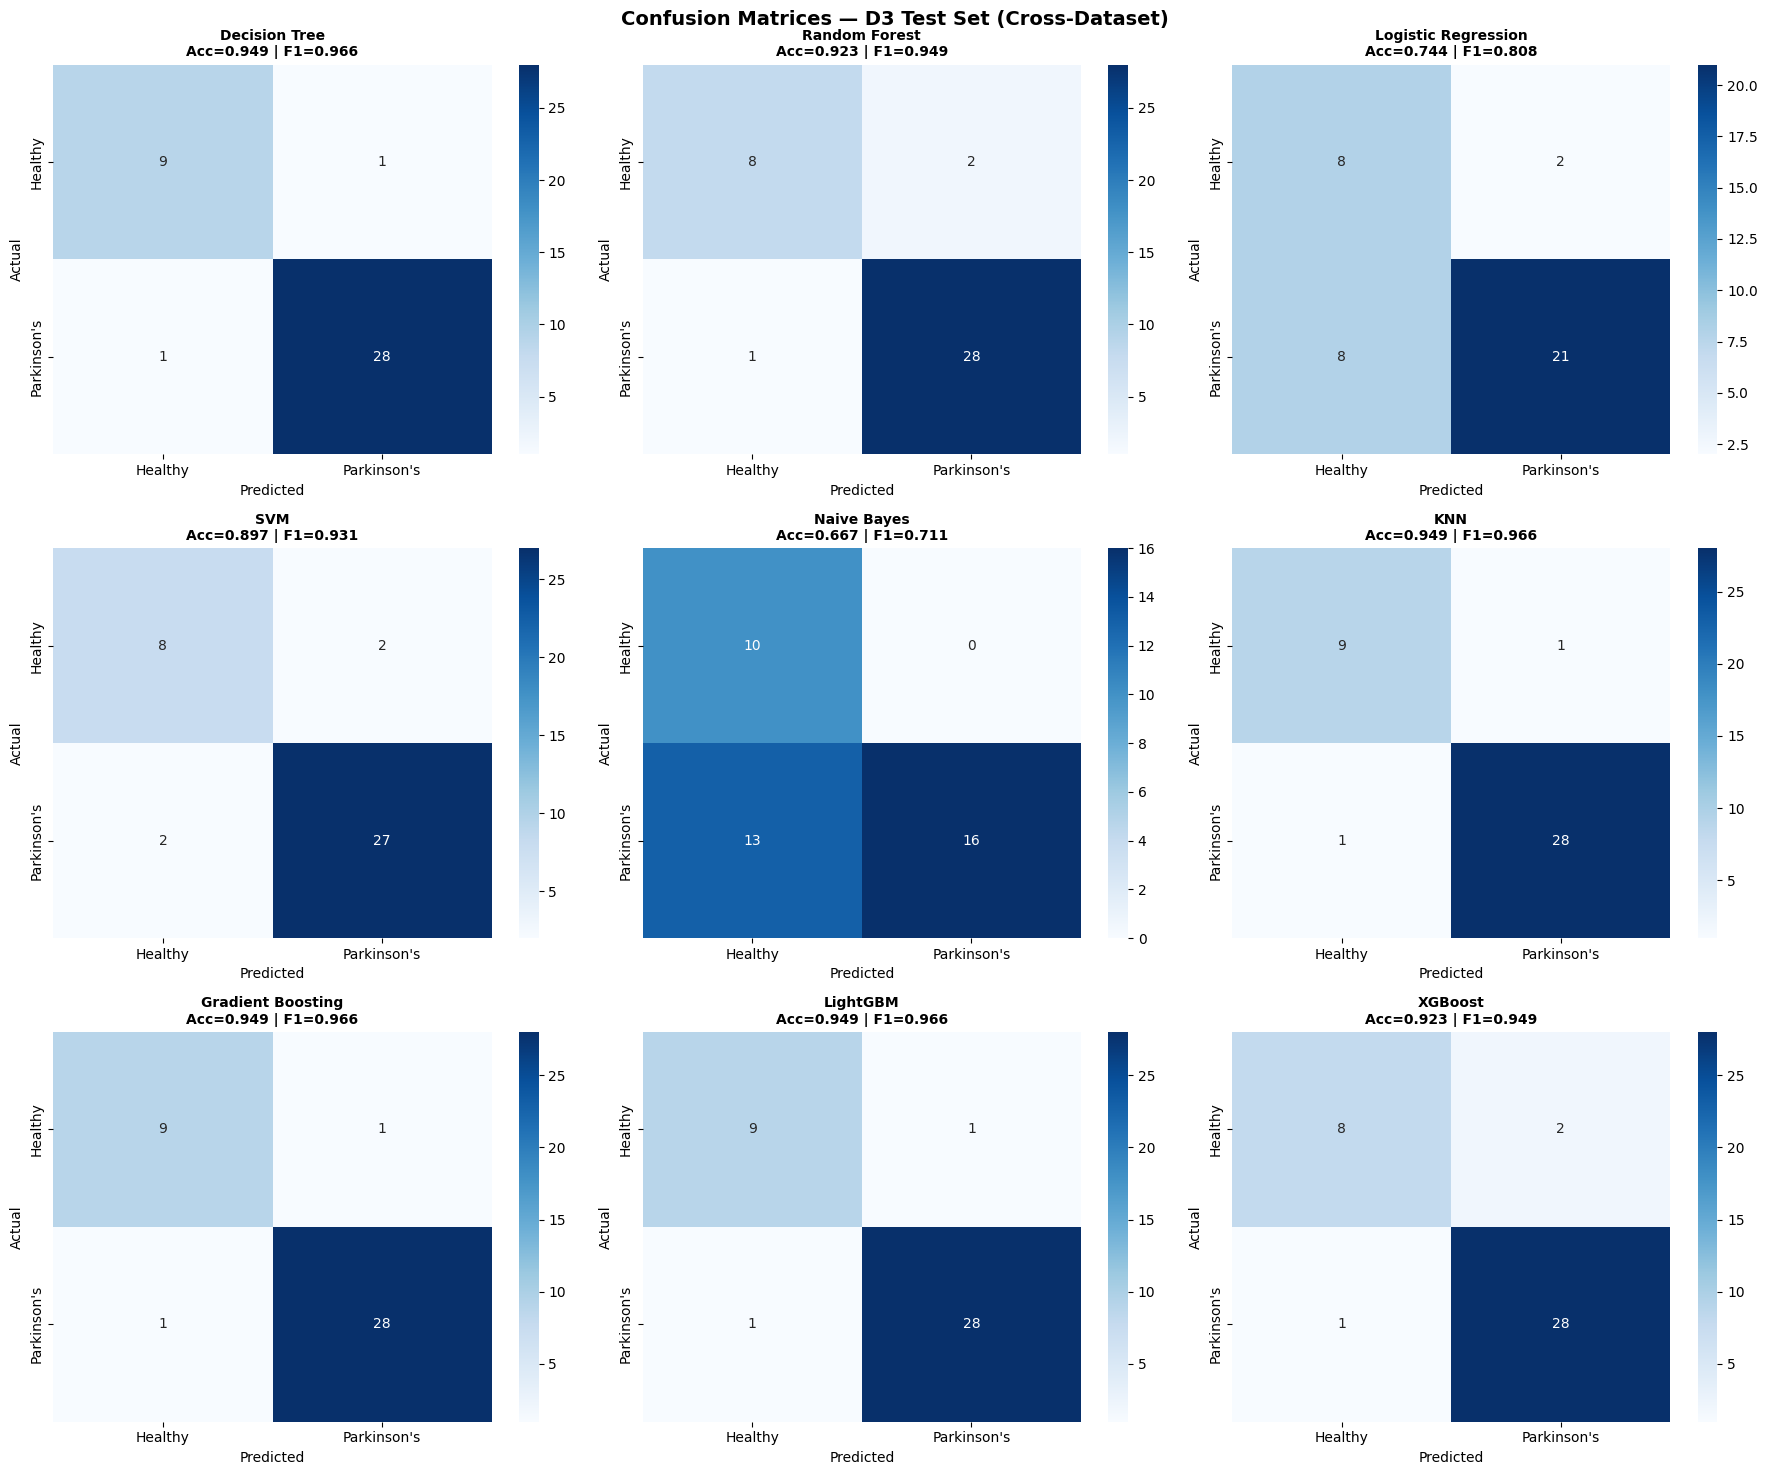

Saved: confusion_matrices_d3.png


In [17]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Confusion Matrices — D3 Test Set (Cross-Dataset)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (model_name, model) in enumerate(tuned_models.items()):
    y_pred = model.predict(X_d3)
    cm     = confusion_matrix(y_d3, y_pred)
    f1     = f1_score(y_d3, y_pred)
    acc    = accuracy_score(y_d3, y_pred)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=['Healthy', "Parkinson's"],
        yticklabels=['Healthy', "Parkinson's"]
    )
    axes[idx].set_title(f'{model_name}\nAcc={acc:.3f} | F1={f1:.3f}', fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_d3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_d3.png')

---
## STEP 14: Performance Comparison Bar Charts (Matching Paper Figure 5)

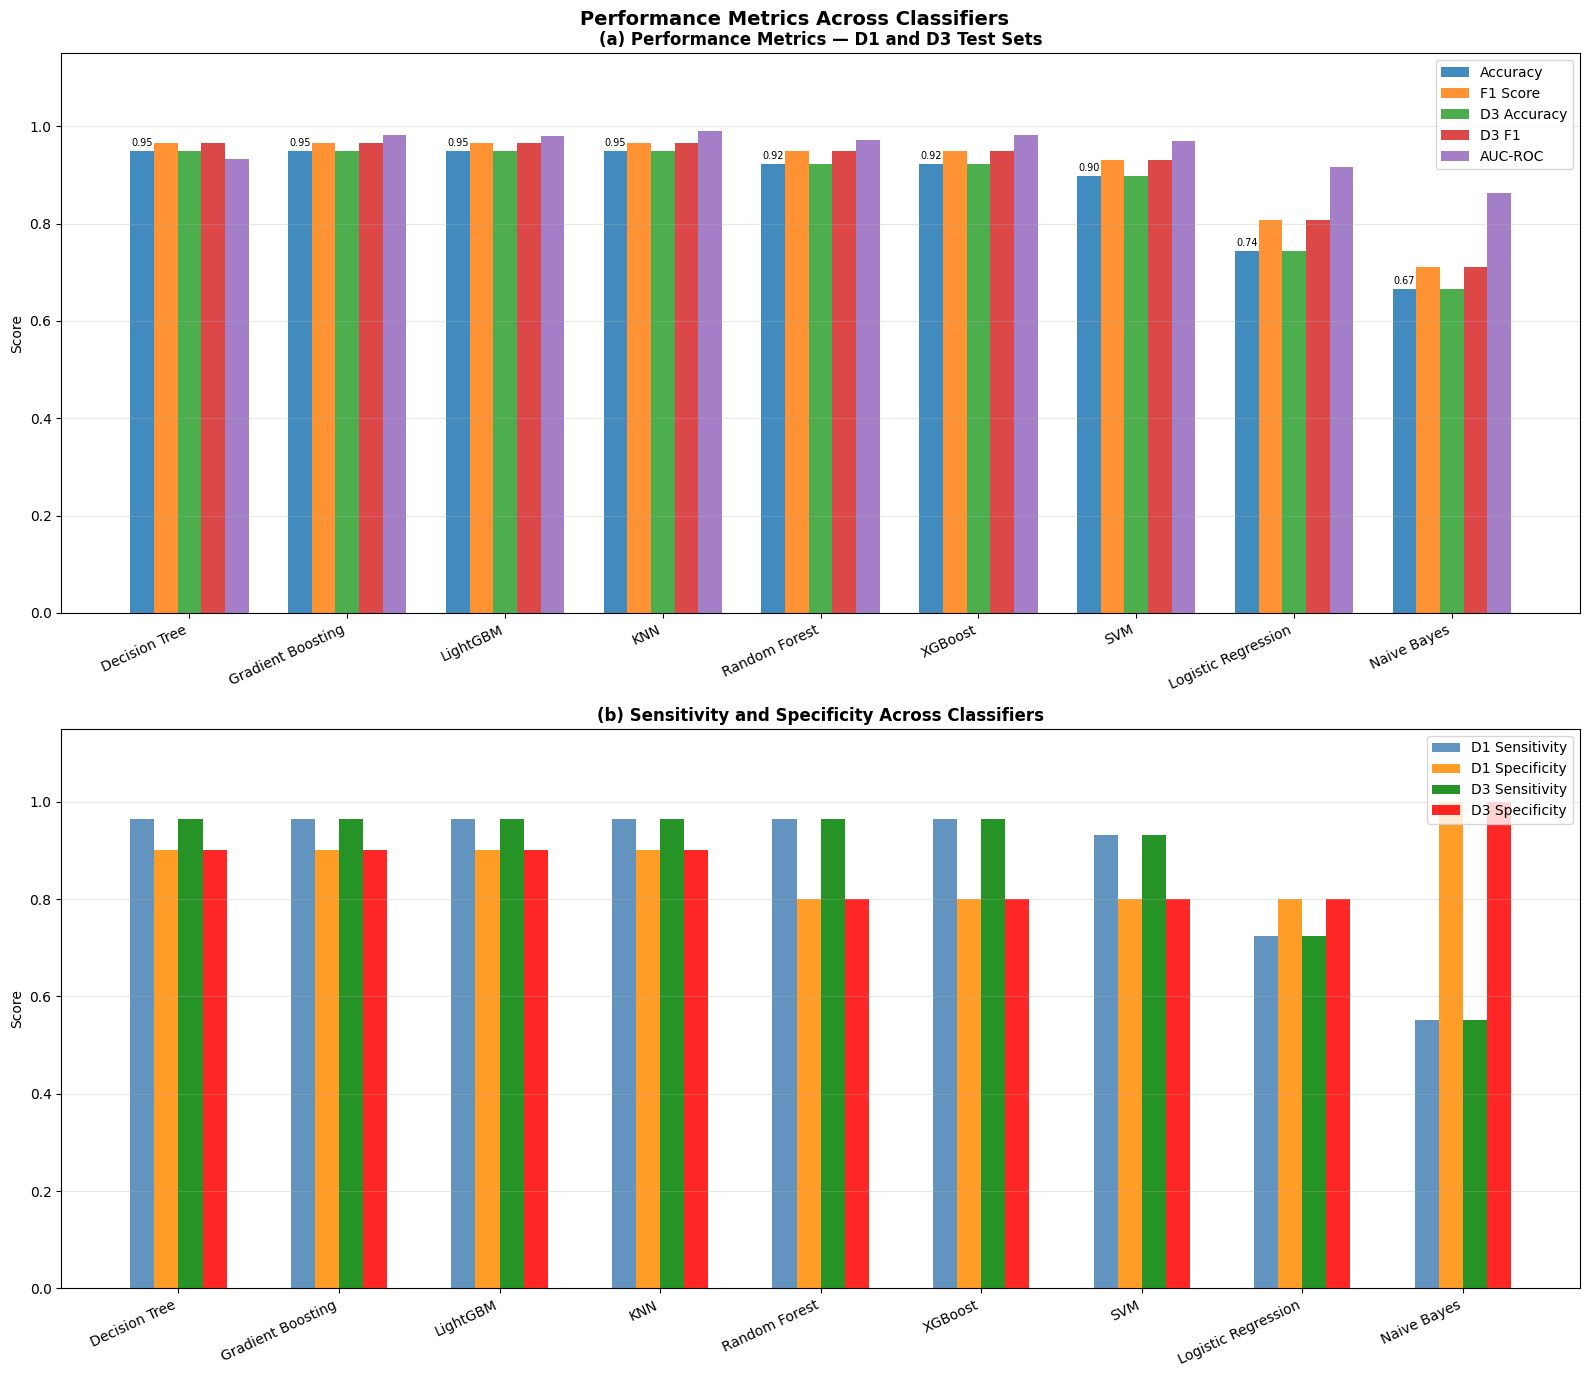

Saved: performance_comparison.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.suptitle('Performance Metrics Across Classifiers', fontsize=14, fontweight='bold')

model_names = tuned_df['Model'].values
x = np.arange(len(model_names))
w = 0.15

# Plot (a) — main metrics
axes[0].bar(x - 2*w, tuned_df['D1 Tuned Acc'], w, label='Accuracy', alpha=0.85)
axes[0].bar(x - w,   tuned_df['D1 Tuned F1'],  w, label='F1 Score', alpha=0.85)
axes[0].bar(x,       tuned_df['D3 Tuned Acc'], w, label='D3 Accuracy', alpha=0.85)
axes[0].bar(x + w,   tuned_df['D3 Tuned F1'],  w, label='D3 F1', alpha=0.85)
axes[0].bar(x + 2*w, tuned_df['D1 Tuned AUC'], w, label='AUC-ROC', alpha=0.85)
axes[0].set_title('(a) Performance Metrics — D1 and D3 Test Sets', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=25, ha='right')
axes[0].legend()
axes[0].set_ylim([0, 1.15])
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(tuned_df['D1 Tuned Acc']):
    axes[0].text(i - 2*w, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)

# Plot (b) — Sensitivity and Specificity
d1_sens = [evaluate_model(tuned_models[m], X_val, y_val, '')[0]['Sensitivity']
           for m in tuned_df['Model']]
d1_spec = [evaluate_model(tuned_models[m], X_val, y_val, '')[0]['Specificity']
           for m in tuned_df['Model']]
d3_sens = [evaluate_model(tuned_models[m], X_d3, y_d3, '')[0]['Sensitivity']
           for m in tuned_df['Model']]
d3_spec = [evaluate_model(tuned_models[m], X_d3, y_d3, '')[0]['Specificity']
           for m in tuned_df['Model']]

axes[1].bar(x - 1.5*w, d1_sens, w, label='D1 Sensitivity', alpha=0.85, color='steelblue')
axes[1].bar(x - 0.5*w, d1_spec, w, label='D1 Specificity', alpha=0.85, color='darkorange')
axes[1].bar(x + 0.5*w, d3_sens, w, label='D3 Sensitivity', alpha=0.85, color='green')
axes[1].bar(x + 1.5*w, d3_spec, w, label='D3 Specificity', alpha=0.85, color='red')
axes[1].set_title('(b) Sensitivity and Specificity Across Classifiers', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=25, ha='right')
axes[1].legend()
axes[1].set_ylim([0, 1.15])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: performance_comparison.png')

---
## STEP 15: Final Summary

In [19]:
best_model_name = tuned_df.iloc[0]['Model']
best_model      = tuned_models[best_model_name]

print('='*80)
print('FINAL SUMMARY')
print('='*80)
print(f'\nDataset: UCI Parkinson\'s Voice Data')
print(f'Training: D1 ({len(X_train)} samples) | Validation: D1 Test ({len(X_val)} samples)')
print(f'Cross-dataset test: D3 ({len(X_d3)} samples)')
print(f'Features: {X_train.shape[1]}')
print(f'Cross-validation: 10-fold Stratified')
print(f'Tuning: GridSearchCV')

print(f'\nALL MODELS — TUNED RESULTS:')
print(tuned_df[['Model', 'D1 Tuned Acc', 'D1 Tuned F1', 'D3 Tuned Acc', 'D3 Tuned F1', 'D3 Tuned AUC']].to_string(index=False))

print(f'\nBEST MODEL: {best_model_name}')
final_m, _, _ = evaluate_model(best_model, X_d3, y_d3, 'D3 Final')
for metric, value in final_m.items():
    if metric != 'Dataset':
        print(f'  {metric:15}: {value}')

print('\nCOMPARISON WITH PAPER:')
print('  Paper best model  : LightGBM — Accuracy 0.983, F1 0.981')
print(f'  My best model    : {best_model_name} — Accuracy {tuned_df.iloc[0]["D1 Tuned Acc"]:.4f}, F1 {tuned_df.iloc[0]["D1 Tuned F1"]:.4f}')
print(f'  My D3 cross-test : {best_model_name} — Accuracy {tuned_df.iloc[0]["D3 Tuned Acc"]:.4f}, F1 {tuned_df.iloc[0]["D3 Tuned F1"]:.4f}')
print('  Paper does not evaluate cross-dataset generalization — this is my extension')

print('\nFILES SAVED:')
for f in ['full_results.csv', 'table1_classification_report.csv',
          'table2_sensitivity_specificity.csv', 'table3_crossdataset_results.csv',
          'tuned_results.csv', 'roc_curves_all_models.png',
          'confusion_matrices_d3.png', 'performance_comparison.png']:
    print(f'  - {f}')

print('\n' + '='*80)
print('SUPERVISED LEARNING COMPLETE')
print('='*80)

FINAL SUMMARY

Dataset: UCI Parkinson's Voice Data
Training: D1 (156 samples) | Validation: D1 Test (39 samples)
Cross-dataset test: D3 (39 samples)
Features: 22
Cross-validation: 10-fold Stratified
Tuning: GridSearchCV

ALL MODELS — TUNED RESULTS:
              Model  D1 Tuned Acc  D1 Tuned F1  D3 Tuned Acc  D3 Tuned F1  D3 Tuned AUC
      Decision Tree      0.948718     0.965517      0.948718     0.965517      0.932759
  Gradient Boosting      0.948718     0.965517      0.948718     0.965517      0.982759
           LightGBM      0.948718     0.965517      0.948718     0.965517      0.979310
                KNN      0.948718     0.965517      0.948718     0.965517      0.989655
      Random Forest      0.923077     0.949153      0.923077     0.949153      0.972414
            XGBoost      0.923077     0.949153      0.923077     0.949153      0.982759
                SVM      0.897436     0.931034      0.897436     0.931034      0.968966
Logistic Regression      0.743590     0.807692 

In [20]:
from google.colab import files
files.download('full_results.csv')
files.download('tuned_results.csv')
files.download('table1_classification_report.csv')
files.download('table2_sensitivity_specificity.csv')
files.download('table3_crossdataset_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>